In [3]:
!ls akinori_data

Barbados_daily_dustFe.xlsx Miami_daily_dustFe.xlsx
Ito_SciAdv_SOLAS.xlsx


In [4]:
import pandas as pd
import numpy as np
import xarray as xr

In [19]:
!pip install openpyxl 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [43]:
barbs = pd.read_excel('akinori_data/Barbados_daily_dustFe.xlsx', header=0, skiprows=[0])
barbs

,Stn,DateOn,DateOff,Dust,Fe,simulated years,2007-2011,1 Mar 2009-28 Feb 2010,2014,2008,Unnamed: 10
0,NaN,NaN,NaN,Ash*1.3,3% iron by weight in the dust,NaT,CAM4,GEOS-Chem,IMPACT,TM4-ECPL,Mean
1,NaN,NaN,NaN,(ug/m3),0.03,NaT,NaN,NaN,NaN,NaN,NaN
2,BAR,2/18/1973,2/19/1973,0.11,0.0033,2026-01-01,0.074248,0.028224,0.423081,0.020583,0.136534
3,BAR,2/19/1973,2/20/1973,0.67,0.0201,2026-01-02,0.153288,0.024142,0.077708,0.021252,0.069098
4,BAR,2/20/1973,2/21/1973,0.11,0.0033,2026-01-03,0.525999,0.119363,0.010153,0.024054,0.169892
...,...,...,...,...,...,...,...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683,0.50049,NaT,NaN,NaN,NaN,NaN,NaN
12959,BAR,8/20/2017,8/21/2017,59.45,1.7835,NaT,NaN,NaN,NaN,NaN,NaN
12960,BAR,8/22/2017,8/23/2017,44.932,1.34796,NaT,NaN,NaN,NaN,NaN,NaN
12961,BAR,8/23/2017,8/24/2017,26.237,0.78711,NaT,NaN,NaN,NaN,NaN,NaN


In [44]:
barbs = barbs.iloc[2:]
barbs

,Stn,DateOn,DateOff,Dust,Fe,simulated years,2007-2011,1 Mar 2009-28 Feb 2010,2014,2008,Unnamed: 10
2,BAR,2/18/1973,2/19/1973,0.11,0.0033,2026-01-01,0.074248,0.028224,0.423081,0.020583,0.136534
3,BAR,2/19/1973,2/20/1973,0.67,0.0201,2026-01-02,0.153288,0.024142,0.077708,0.021252,0.069098
4,BAR,2/20/1973,2/21/1973,0.11,0.0033,2026-01-03,0.525999,0.119363,0.010153,0.024054,0.169892
5,BAR,2/21/1973,2/22/1973,0.28,0.0084,2026-01-04,0.977052,0.100202,0.007279,0.071761,0.289073
6,BAR,2/22/1973,2/23/1973,0.19,0.0057,2026-01-05,0.726511,0.100054,0.218952,0.318656,0.341043
...,...,...,...,...,...,...,...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683,0.50049,NaT,NaN,NaN,NaN,NaN,NaN
12959,BAR,8/20/2017,8/21/2017,59.45,1.7835,NaT,NaN,NaN,NaN,NaN,NaN
12960,BAR,8/22/2017,8/23/2017,44.932,1.34796,NaT,NaN,NaN,NaN,NaN,NaN
12961,BAR,8/23/2017,8/24/2017,26.237,0.78711,NaT,NaN,NaN,NaN,NaN,NaN


In [45]:
barbs['Dust'] = barbs['Dust'].astype(str).str.replace(',', '').str.strip()
barbs['Dust'] = pd.to_numeric(barbs['Dust'], errors='coerce')
barbs

/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_2531/1290544900.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barbs['Dust'] = barbs['Dust'].astype(str).str.replace(',', '').str.strip()
/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_2531/1290544900.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barbs['Dust'] = pd.to_numeric(barbs['Dust'], errors='coerce')


,Stn,DateOn,DateOff,Dust,Fe,simulated years,2007-2011,1 Mar 2009-28 Feb 2010,2014,2008,Unnamed: 10
2,BAR,2/18/1973,2/19/1973,0.110,0.0033,2026-01-01,0.074248,0.028224,0.423081,0.020583,0.136534
3,BAR,2/19/1973,2/20/1973,0.670,0.0201,2026-01-02,0.153288,0.024142,0.077708,0.021252,0.069098
4,BAR,2/20/1973,2/21/1973,0.110,0.0033,2026-01-03,0.525999,0.119363,0.010153,0.024054,0.169892
5,BAR,2/21/1973,2/22/1973,0.280,0.0084,2026-01-04,0.977052,0.100202,0.007279,0.071761,0.289073
6,BAR,2/22/1973,2/23/1973,0.190,0.0057,2026-01-05,0.726511,0.100054,0.218952,0.318656,0.341043
...,...,...,...,...,...,...,...,...,...,...,...
12958,BAR,8/19/2017,8/20/2017,16.683,0.50049,NaT,NaN,NaN,NaN,NaN,NaN
12959,BAR,8/20/2017,8/21/2017,59.450,1.7835,NaT,NaN,NaN,NaN,NaN,NaN
12960,BAR,8/22/2017,8/23/2017,44.932,1.34796,NaT,NaN,NaN,NaN,NaN,NaN
12961,BAR,8/23/2017,8/24/2017,26.237,0.78711,NaT,NaN,NaN,NaN,NaN,NaN


In [53]:
barbs.DateOn = barbs.DateOn.astype('datetime64[ns]')
barbs.DateOff =  barbs.DateOff.astype('datetime64[ns]')
barbs

,Stn,DateOn,DateOff,Dust,Fe,simulated years,2007-2011,1 Mar 2009-28 Feb 2010,2014,2008,Unnamed: 10
2,BAR,1973-02-18,1973-02-19,0.110,0.0033,2026-01-01,0.074248,0.028224,0.423081,0.020583,0.136534
3,BAR,1973-02-19,1973-02-20,0.670,0.0201,2026-01-02,0.153288,0.024142,0.077708,0.021252,0.069098
4,BAR,1973-02-20,1973-02-21,0.110,0.0033,2026-01-03,0.525999,0.119363,0.010153,0.024054,0.169892
5,BAR,1973-02-21,1973-02-22,0.280,0.0084,2026-01-04,0.977052,0.100202,0.007279,0.071761,0.289073
6,BAR,1973-02-22,1973-02-23,0.190,0.0057,2026-01-05,0.726511,0.100054,0.218952,0.318656,0.341043
...,...,...,...,...,...,...,...,...,...,...,...
12958,BAR,2017-08-19,2017-08-20,16.683,0.50049,NaT,NaN,NaN,NaN,NaN,NaN
12959,BAR,2017-08-20,2017-08-21,59.450,1.7835,NaT,NaN,NaN,NaN,NaN,NaN
12960,BAR,2017-08-22,2017-08-23,44.932,1.34796,NaT,NaN,NaN,NaN,NaN,NaN
12961,BAR,2017-08-23,2017-08-24,26.237,0.78711,NaT,NaN,NaN,NaN,NaN,NaN


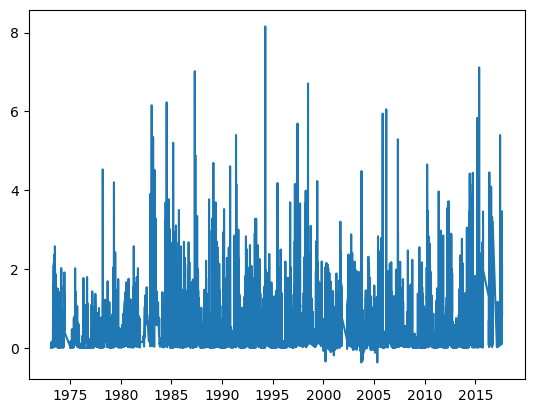

In [65]:
plt.plot(barbs.DateOn, barbs.Fe)

NameError: name 'DateOn' is not defined

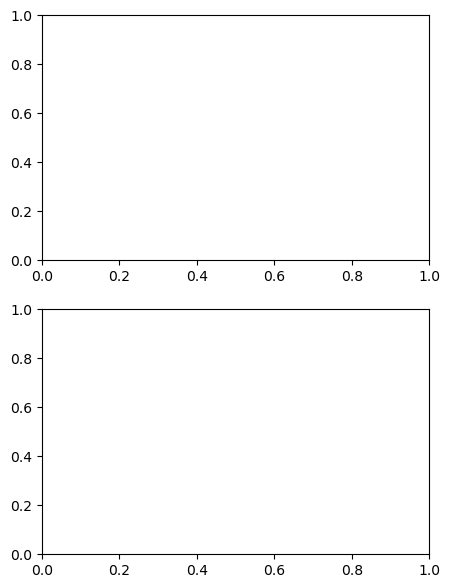

In [61]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(2,1,figsize=(5,7))
barbs.Fe.plot(x=DateOn,ax=ax[0])
barbs.Fe.rolling(100).mean().plot(ax=ax[1])

In [69]:
import pandas as pd
import xarray as xr
import numpy as np

# ── 1. Load & clean ──────────────────────────────────────────────────────────
raw = pd.read_excel('akinori_data/Barbados_daily_dustFe.xlsx', header=None)

# Build proper column names from the two header rows
col_names = ['Stn', 'DateOn', 'DateOff', 'Dust_ug_m3', 'Fe_ug_m3',
             'simulated_years', 'CAM4', 'GEOS-Chem', 'IMPACT', 'TM4-ECPL', 'Mean']

# Skip the 4 metadata rows (rows 0-3), assign clean column names
df = raw.iloc[4:].copy()
df.columns = col_names
df = df.reset_index(drop=True)

# ── 2. Parse dates & cast numerics ───────────────────────────────────────────
df['DateOn']  = pd.to_datetime(df['DateOn'],  dayfirst=False)
df['DateOff'] = pd.to_datetime(df['DateOff'], dayfirst=False)

numeric_cols = ['Dust_ug_m3', 'Fe_ug_m3', 'CAM4', 'GEOS-Chem', 'IMPACT', 'TM4-ECPL', 'Mean']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Use DateOn as the time coordinate
df = df.set_index('DateOn').sort_index()

# ── 3. Build xarray Dataset ───────────────────────────────────────────────────
ds = xr.Dataset(
    {
        'Dust':      ('time', df['Dust_ug_m3'].values),
        'Fe':        ('time', df['Fe_ug_m3'].values),
        'CAM4':      ('time', df['CAM4'].values),
        'GEOS_Chem': ('time', df['GEOS-Chem'].values),
        'IMPACT':    ('time', df['IMPACT'].values),
        'TM4_ECPL':  ('time', df['TM4-ECPL'].values),
        'Mean':      ('time', df['Mean'].values),
    },
    coords={
        'time':   df.index.values,
        'DateOff': ('time', df['DateOff'].values),
        'station': df['Stn'].values,
    },
    attrs={
        'title':  'Barbados Dust Mass Concentrations',
        'period': 'Feb 1973 – Aug 2017',
        'Dust_units': 'ug/m3 (Ash*1.3)',
        'Fe_units':   'ug/m3 (3% Fe by weight, factor=0.03)',
    }
)

print(ds)

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 12961, station: 12961)
Coordinates:
  * time       (time) datetime64[ns] 104kB 1973-02-18 1973-02-19 ... 2017-08-24
    DateOff    (time) datetime64[ns] 104kB 1973-02-19 1973-02-20 ... 2017-08-25
  * station    (station) object 104kB 'BAR' 'BAR' 'BAR' ... 'BAR' 'BAR' 'BAR'
Data variables:
    Dust       (time) float64 104kB 0.11 0.67 0.11 0.28 ... 44.93 26.24 69.27
    Fe         (time) float64 104kB 0.0033 0.0201 0.0033 ... 1.348 0.7871 2.078
    CAM4       (time) float64 104kB 0.07425 0.1533 0.526 0.9771 ... nan nan nan
    GEOS_Chem  (time) float64 104kB 0.02822 0.02414 0.1194 ... nan nan nan
    IMPACT     (time) float64 104kB 0.4231 0.07771 0.01015 ... nan nan nan
    TM4_ECPL   (time) float64 104kB 0.02058 0.02125 0.02405 ... nan nan nan
    Mean       (time) float64 104kB 0.1365 0.0691 0.1699 0.2891 ... nan nan nan
Attributes:
    title:       Barbados Dust Mass Concentrations
    period:      Feb 1973 – Aug 2017
    Dust_units:  

In [70]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 12961, station: 12961)
Coordinates:
  * time       (time) datetime64[ns] 104kB 1973-02-18 1973-02-19 ... 2017-08-24
    DateOff    (time) datetime64[ns] 104kB 1973-02-19 1973-02-20 ... 2017-08-25
  * station    (station) object 104kB 'BAR' 'BAR' 'BAR' ... 'BAR' 'BAR' 'BAR'
Data variables:
    Dust       (time) float64 104kB 0.11 0.67 0.11 0.28 ... 44.93 26.24 69.27
    Fe         (time) float64 104kB 0.0033 0.0201 0.0033 ... 1.348 0.7871 2.078
    CAM4       (time) float64 104kB 0.07425 0.1533 0.526 0.9771 ... nan nan nan
    GEOS_Chem  (time) float64 104kB 0.02822 0.02414 0.1194 ... nan nan nan
    IMPACT     (time) float64 104kB 0.4231 0.07771 0.01015 ... nan nan nan
    TM4_ECPL   (time) float64 104kB 0.02058 0.02125 0.02405 ... nan nan nan
    Mean       (time) float64 104kB 0.1365 0.0691 0.1699 0.2891 ... nan nan nan
Attributes:
    title:       Barbados Dust Mass Concentrations
    period:      Feb 1973 – Aug 2017
    Dust_units:  ug/m3 (Ash*1.3)
    Fe_units:    ug/m3 (3% Fe by weight, factor=0.03)

In [79]:
import pandas as pd
import xarray as xr
import numpy as np

# ════════════════════════════════════════════════════════════════════
# 1. MIAMI
# ════════════════════════════════════════════════════════════════════
raw_mia = pd.read_excel('akinori_data/Miami_daily_dustFe.xlsx', header=None)

col_names_mia = ['Stn', 'DateOn', 'DateOff', 'Dust_ug_m3', 'Fe_ug_m3',
                 '_drop', 'Notes', 'simulated_years',
                 'CAM4', 'GEOS-Chem', 'IMPACT', 'TM4-ECPL', 'Mean']

df_mia = raw_mia.iloc[5:].copy()          # 5 header/metadata rows
df_mia.columns = col_names_mia
df_mia = df_mia.drop(columns=['_drop']).reset_index(drop=True)

df_mia['DateOn']  = pd.to_datetime(df_mia['DateOn'],  dayfirst=False)
df_mia['DateOff'] = pd.to_datetime(df_mia['DateOff'], dayfirst=False)

numeric_mia = ['Dust_ug_m3', 'Fe_ug_m3', 'CAM4', 'GEOS-Chem', 'IMPACT', 'TM4-ECPL', 'Mean']
df_mia[numeric_mia] = df_mia[numeric_mia].apply(pd.to_numeric, errors='coerce')
df_mia = df_mia.set_index('DateOn').sort_index()

ds_miami = xr.Dataset(
    {
        'Dust':      ('time', df_mia['Dust_ug_m3'].values),
        'Fe':        ('time', df_mia['Fe_ug_m3'].values),
        'CAM4':      ('time', df_mia['CAM4'].values),
        'GEOS_Chem': ('time', df_mia['GEOS-Chem'].values),
        'IMPACT':    ('time', df_mia['IMPACT'].values),
        'TM4_ECPL':  ('time', df_mia['TM4-ECPL'].values),
        'Mean':      ('time', df_mia['Mean'].values),
        'Notes':     ('time', df_mia['Notes'].values),
    },
    coords={
        'time':    df_mia.index.values,
        'DateOff': ('time', df_mia['DateOff'].values),
        'station': ('time', df_mia['Stn'].values),
    },
    attrs={
        'title':      'Miami Dust Mass Concentrations',
        'period':     'Jul 1974 – Dec 2018',
        'Dust_units': 'ug/m3 (Ash*1.3)',
        'Fe_units':   'ug/m3 (3% Fe by weight, factor=0.03)',
    }
)

print(ds_miami)


# ════════════════════════════════════════════════════════════════════
# 2. ITO et al. (SciAdv / SOLAS)
# ════════════════════════════════════════════════════════════════════
raw_ito = pd.read_excel('akinori_data/Ito_SciAdv_SOLAS.xlsx', header=None)

# Build multi-level column names from rows 0 and 1
group_row = raw_ito.iloc[0].ffill()   # forward-fill merged group headers
var_row   = raw_ito.iloc[1]

col_names_ito = [
    'obsnum', 'OCEAN', 'lon', 'lat',
    # Total Fe concentration (ng/m3)
    'TotalFe_obs', 'TotalFe_IMPACT', 'TotalFe_TM4ECPL', 'TotalFe_CAM4', 'TotalFe_GEOS',
    # Fe solubility (%) for all sources
    'FeSol_obs', 'FeSol_IMPACT', 'FeSol_TM4ECPL', 'FeSol_CAM4', 'FeSol_GEOS',
    # Fe solubility (%) for combustion and dust sources
    'FeSol_comb_dust_IMPACT_comb', 'FeSol_comb_dust_IMPACT_dust',
    'FeSol_comb_dust_TM4ECPL_comb', 'FeSol_comb_dust_TM4ECPL_dust',  # note: col17 is NaN in raw
    'FeSol_comb_dust_CAM4_comb', 'FeSol_comb_dust_CAM4_dust',
    '_drop',
    # Contribution of soluble Fe from combustion (%)
    'SolFe_comb_contrib_IMPACT', 'SolFe_comb_contrib_TM4ECPL', 'SolFe_comb_contrib_CAM4',
]

# Pad if needed
while len(col_names_ito) < raw_ito.shape[1]:
    col_names_ito.append(f'_col{len(col_names_ito)}')

df_ito = raw_ito.iloc[2:].copy()
df_ito.columns = col_names_ito[:df_ito.shape[1]]
df_ito = df_ito.drop(columns=[c for c in df_ito.columns if c.startswith('_')])
df_ito = df_ito.reset_index(drop=True)

numeric_ito = [c for c in df_ito.columns if c not in ('OCEAN',)]
df_ito[numeric_ito] = df_ito[numeric_ito].apply(pd.to_numeric, errors='coerce')

ds_ito = xr.Dataset(
    {col: ('obs', df_ito[col].values)
     for col in df_ito.columns if col not in ('obsnum', 'OCEAN', 'lon', 'lat')},
    coords={
        'obs':    df_ito['obsnum'].values.astype(int),
        'lon':    ('obs', df_ito['lon'].values),
        'lat':    ('obs', df_ito['lat'].values),
        'ocean':  ('obs', df_ito['OCEAN'].values),
    },
    attrs={
        'title':      'Ito et al. SciAdv/SOLAS — Fe observations & model comparison',
        'TotalFe_units': 'ng/m3',
        'FeSol_units':   '%',
    }
)

print(ds_ito)

<xarray.Dataset> Size: 616kB
Dimensions:    (time: 7004)
Coordinates:
  * time       (time) datetime64[ns] 56kB 1974-07-02 1974-07-03 ... 2018-11-28
    DateOff    (time) datetime64[ns] 56kB 1974-07-03 1974-07-04 ... 2018-12-05
    station    (time) object 56kB 'MIA' 'MIA' 'MIA' 'MIA' ... 'MIA' 'MIA' 'MIA'
Data variables:
    Dust       (time) float64 56kB 9.908 10.9 4.686 0.788 ... 0.369 0.623 0.493
    Fe         (time) float64 56kB 0.2972 0.3271 0.1406 ... 0.01869 0.01479
    CAM4       (time) float64 56kB 0.001243 0.002507 0.002998 ... nan nan nan
    GEOS_Chem  (time) float64 56kB 0.00287 0.007958 0.01612 ... nan nan nan
    IMPACT     (time) float64 56kB 0.0001178 0.0001445 0.00044 ... nan nan nan
    TM4_ECPL   (time) float64 56kB 0.005319 0.01219 0.009407 ... nan nan nan
    Mean       (time) float64 56kB 0.002388 0.005699 0.007241 ... nan nan nan
    Notes      (time) object 56kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    title:       Miami Dust Mass Concentra

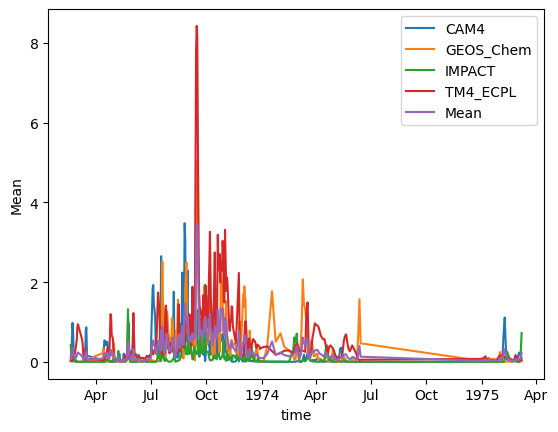

In [81]:
# ds.Dust.plot()
# ds.Fe.plot()
ds.CAM4.plot(label='CAM4')
ds.GEOS_Chem.plot(label='GEOS_Chem')
ds.IMPACT.plot(label='IMPACT')
ds.TM4_ECPL.plot(label='TM4_ECPL')
ds.Mean.plot(label='Mean')

plt.legend()

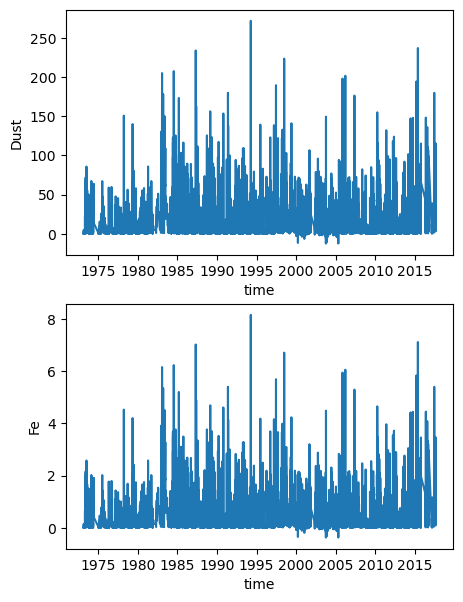

In [80]:
fig,ax = plt.subplots(2,1,figsize=(5,7))
ds.Dust.plot(ax=ax[0])
ds.Fe.plot(ax=ax[1])

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/xarray/groupers.py:509: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/xarray/groupers.py:509: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/xarray/groupers.py:509: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/xarray/groupers.py:509: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


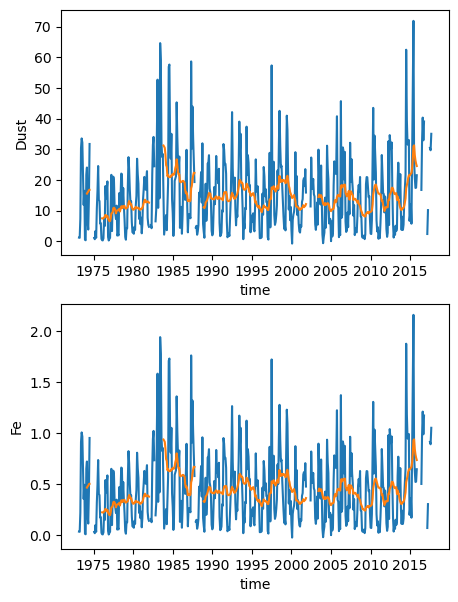

In [89]:
fig,ax = plt.subplots(2,1,figsize=(5,7))
ds.Dust.resample(time='M').mean().plot(ax=ax[0])
ds.Fe.resample(time='M').mean().plot(ax=ax[1])
#rolling means of 13 months
ds.Dust.resample(time='M').mean().rolling(time=13).mean().plot(ax=ax[0])
ds.Fe.resample(time='M').mean().rolling(time=13).mean().plot(ax=ax[1])

In [132]:
def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

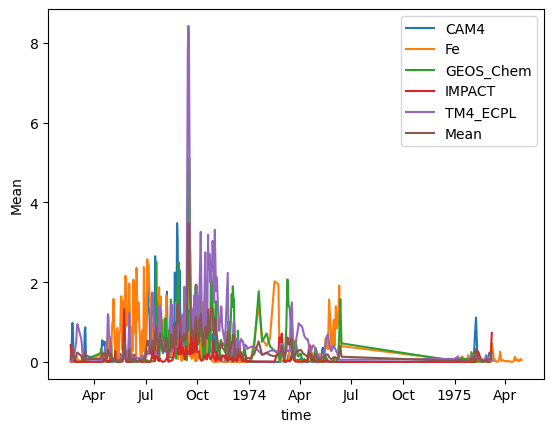

In [133]:
ds.CAM4.sel(time=slice(None,'1975-04')).plot(label='CAM4')
ds.Fe.sel(time=slice(None,'1975-04')).plot(label='Fe')
ds.GEOS_Chem.sel(time=slice(None,'1975-04')).plot(label='GEOS_Chem')
ds.IMPACT.sel(time=slice(None,'1975-04')).plot(label='IMPACT')
ds.TM4_ECPL.sel(time=slice(None,'1975-04')).plot(label='TM4_ECPL')
ds.Mean.sel(time=slice(None,'1975-04')).plot(label='Mean')
plt.legend()

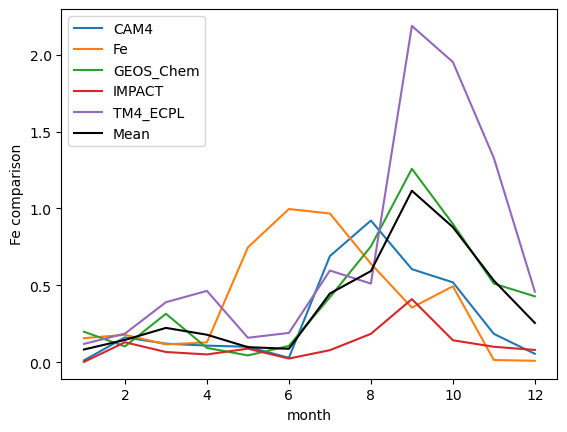

In [134]:
monthly_mean(ds.CAM4.sel(time=slice(None,'1975-04'))).plot(label='CAM4')
monthly_mean(ds.Fe.sel(time=slice(None,'1975-04'))).plot(label='Fe')
monthly_mean(ds.GEOS_Chem.sel(time=slice(None,'1975-04'))).plot(label='GEOS_Chem')
monthly_mean(ds.IMPACT.sel(time=slice(None,'1975-04'))).plot(label='IMPACT')
monthly_mean(ds.TM4_ECPL.sel(time=slice(None,'1975-04'))).plot(label='TM4_ECPL')
monthly_mean(ds.Mean.sel(time=slice(None,'1975-04'))).rename('Fe comparison').plot(label='Mean', color='k')
plt.legend()

plt.savefig('barbados_seasonal.png', dpi=150, bbox_inches='tight')


In [126]:
ds.Fe.time

<xarray.DataArray 'time' (time: 12961)> Size: 104kB
array(['1973-02-18T00:00:00.000000000', '1973-02-19T00:00:00.000000000',
       '1973-02-20T00:00:00.000000000', ..., '2017-08-22T00:00:00.000000000',
       '2017-08-23T00:00:00.000000000', '2017-08-24T00:00:00.000000000'],
      shape=(12961,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 104kB 1973-02-18 1973-02-19 ... 2017-08-24
    DateOff  (time) datetime64[ns] 104kB 1973-02-19 1973-02-20 ... 2017-08-25

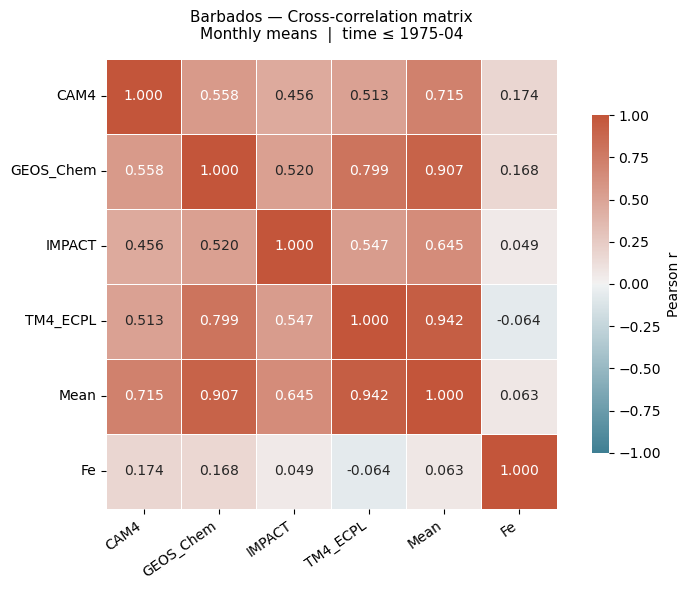

            CAM4  GEOS_Chem  IMPACT  TM4_ECPL   Mean     Fe
CAM4       1.000      0.558   0.456     0.513  0.715  0.174
GEOS_Chem  0.558      1.000   0.520     0.799  0.907  0.168
IMPACT     0.456      0.520   1.000     0.547  0.645  0.049
TM4_ECPL   0.513      0.799   0.547     1.000  0.942 -0.064
Mean       0.715      0.907   0.645     0.942  1.000  0.063
Fe         0.174      0.168   0.049    -0.064  0.063  1.000


In [127]:
# ── Helper: monthly mean ──────────────────────────────────────────────────────
def monthly_mean(da):
    return da.resample(time='ME').mean()

# ── Slice & resample all variables up to 1975-04 ─────────────────────────────
variables = ['CAM4', 'GEOS_Chem', 'IMPACT', 'TM4_ECPL', 'Mean', 'Fe']

sliced = {
    var: monthly_mean(ds[var].sel(time=slice(None, '1975-04')))
    for var in variables
}

# ── Build a combined DataFrame (time as index) ────────────────────────────────
df_monthly = pd.DataFrame(
    {var: sliced[var].values for var in variables},
    index=sliced['Fe'].time.values
)

# ── Correlation matrix ────────────────────────────────────────────────────────
corr = df_monthly.corr()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)

ax.set_title('Barbados — Cross-correlation matrix\n'
             'Monthly means  |  time ≤ 1975-04',
             fontsize=11, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('barbados_crosscorr_monthly_1975.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print table ───────────────────────────────────────────────────────────────
print(corr.round(3).to_string())

In [122]:
ds_miami.CAM4.sel(time=slice(None,'1977-05'))

<xarray.DataArray 'CAM4' (time: 415)> Size: 3kB
array([1.242648e-03, 2.506601e-03, 2.998217e-03, 1.925269e-03,
       1.375493e-03, 4.087201e-03, 4.048297e-03, 3.009674e-03,
       4.807664e-03, 6.441265e-03, 3.493201e-03, 1.983484e-03,
       4.865917e-04, 2.607926e-04, 2.455195e-04, 4.502036e-03,
       9.015634e-03, 7.444721e-03, 2.677341e-02, 3.121446e-02,
       1.948104e-02, 1.013939e-02, 7.819704e-03, 8.384616e-03,
       1.439545e-02, 1.172302e-01, 1.469257e-01, 2.121933e-01,
       1.632198e-01, 1.514950e-01, 1.230491e-01, 7.276826e-02,
       1.641479e-02, 6.488006e-03, 3.140094e-03, 3.027916e-03,
       3.674050e-03, 9.201903e-04, 1.678434e-03, 2.116624e-03,
       1.749475e-03, 1.558832e-03, 7.765795e-04, 1.726616e-03,
       1.785021e-03, 1.508196e-03, 1.425031e-03, 1.824279e-03,
       1.768558e-03, 2.999353e-03, 4.663968e-03, 4.300196e-03,
       3.348849e-03, 1.444103e-03, 6.324303e-04, 2.127955e-03,
       2.725093e-03, 2.744877e-03, 2.832267e-03, 7.117365e-03,
       5.248009e-03, 3.082958e-03, 5.727702e-03, 4.616640e-03,
       7.496833e-03, 4.019732e-02, 5.976002e-02, 1.922611e-02,
       1.154751e-02, 2.234384e-02, 1.207472e-02, 3.358713e-03,
       5.434085e-03, 1.201849e-02, 4.375971e-03, 1.207580e-02,
       1.799033e-02, 1.604971e-02, 4.245136e-03, 1.888542e-03,
...
       5.187623e-04, 2.102886e-03, 4.379615e-03, 4.275322e-03,
       2.122427e-03, 4.551755e-03, 9.404060e-03, 7.560574e-03,
       6.567079e-03, 5.876352e-03, 4.936068e-03, 4.744754e-03,
       4.742641e-03, 8.677904e-04, 1.769054e-04, 2.726297e-04,
       1.465405e-03, 2.125737e-03, 7.724080e-04, 1.369962e-03,
       2.466606e-03, 6.035352e-03, 2.037212e-03, 1.876772e-03,
       7.788896e-04, 5.345792e-04, 1.109504e-03, 7.268406e-03,
       2.829038e-03,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1974-07-02 1974-07-03 ... 1977-05-31
    DateOff  (time) datetime64[ns] 3kB 1974-07-03 1974-07-04 ... 1977-06-01
    station  (time) object 3kB 'MIA' 'MIA' 'MIA' 'MIA' ... 'MIA' 'MIA' 'MIA'

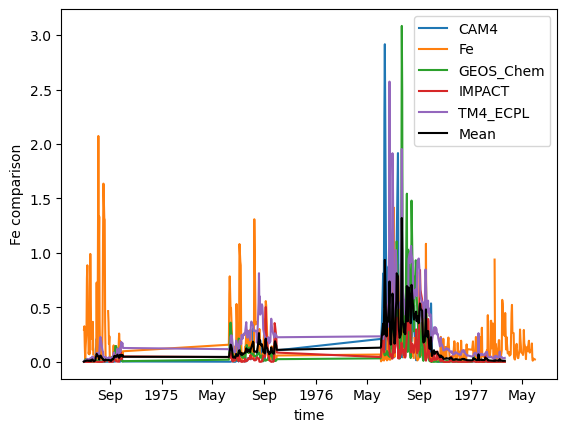

In [136]:
ds_miami.CAM4.sel(time=slice(None,'1977-05')).plot(label='CAM4')
ds_miami.Fe.sel(time=slice(None,'1977-05')).plot(label='Fe')
ds_miami.GEOS_Chem.sel(time=slice(None,'1977-05')).plot(label='GEOS_Chem')
ds_miami.IMPACT.sel(time=slice(None,'1977-05')).plot(label='IMPACT')
ds_miami.TM4_ECPL.sel(time=slice(None,'1977-05')).plot(label='TM4_ECPL')
ds_miami.Mean.sel(time=slice(None,'1977-05')).rename('Fe comparison').plot(label='Mean', color='k')
plt.legend()


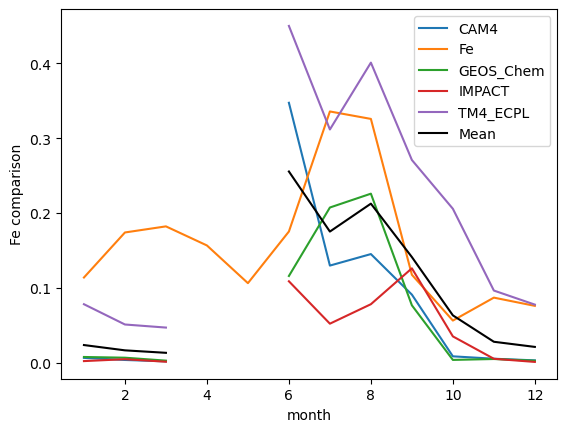

In [135]:
monthly_mean(ds_miami.CAM4.sel(time=slice(None,'1977-05'))).plot(label='CAM4')
monthly_mean(ds_miami.Fe.sel(time=slice(None,'1977-05'))).plot(label='Fe')
monthly_mean(ds_miami.GEOS_Chem.sel(time=slice(None,'1977-05'))).plot(label='GEOS_Chem')
monthly_mean(ds_miami.IMPACT.sel(time=slice(None,'1977-05'))).plot(label='IMPACT')
monthly_mean(ds_miami.TM4_ECPL.sel(time=slice(None,'1977-05'))).plot(label='TM4_ECPL')
monthly_mean(ds_miami.Mean.sel(time=slice(None,'1977-05'))).rename('Fe comparison').plot(label='Mean', color='k')
plt.legend()

plt.savefig('Miami_seasonal_1977.png', dpi=150, bbox_inches='tight')


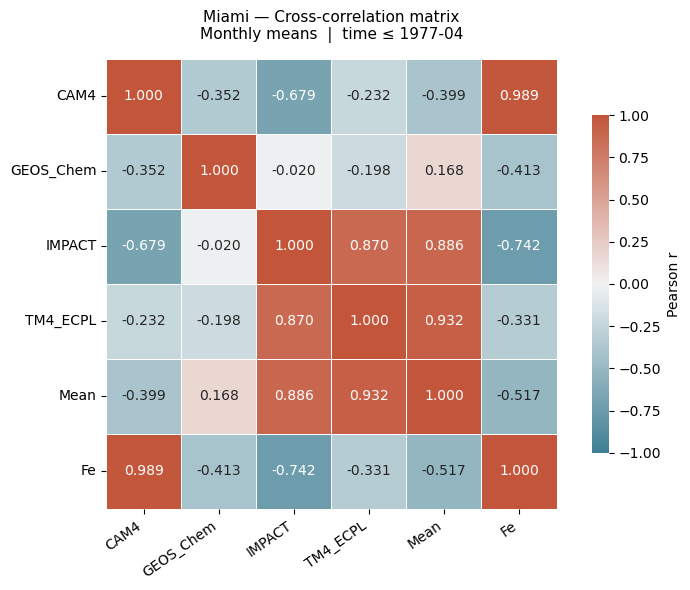

            CAM4  GEOS_Chem  IMPACT  TM4_ECPL   Mean     Fe
CAM4       1.000     -0.352  -0.679    -0.232 -0.399  0.989
GEOS_Chem -0.352      1.000  -0.020    -0.198  0.168 -0.413
IMPACT    -0.679     -0.020   1.000     0.870  0.886 -0.742
TM4_ECPL  -0.232     -0.198   0.870     1.000  0.932 -0.331
Mean      -0.399      0.168   0.886     0.932  1.000 -0.517
Fe         0.989     -0.413  -0.742    -0.331 -0.517  1.000


In [128]:
# ── Slice & resample all variables up to 1975-04 ─────────────────────────────
variables = ['CAM4', 'GEOS_Chem', 'IMPACT', 'TM4_ECPL', 'Mean', 'Fe']

sliced = {
    var: monthly_mean(ds_miami[var].sel(time=slice(None, '1975-04')))
    for var in variables
}

# ── Build a combined DataFrame (time as index) ────────────────────────────────
df_monthly = pd.DataFrame(
    {var: sliced[var].values for var in variables},
    index=sliced['Fe'].time.values
)

# ── Correlation matrix ────────────────────────────────────────────────────────
corr = df_monthly.corr()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)

ax.set_title('Miami — Cross-correlation matrix\n'
             'Monthly means  |  time ≤ 1977-04',
             fontsize=11, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('Miami_crosscorr_monthly_1977.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print table ───────────────────────────────────────────────────────────────
print(corr.round(3).to_string())

### Ito

In [147]:
ds_ito

<xarray.Dataset> Size: 146kB
Dimensions:                       (obs: 795)
Coordinates:
  * obs                           (obs) int64 6kB 16 17 18 19 ... 1040 1041 1042
    lon                           (obs) float64 6kB 80.3 81.8 ... 297.7 295.4
    lat                           (obs) float64 6kB 13.1 15.49 ... -56.88 -55.62
    ocean                         (obs) object 6kB 'Bay_of_Bengal' ... 'SO At...
Data variables: (12/19)
    TotalFe_obs                   (obs) float64 6kB 908.9 666.5 ... 8.385 10.32
    TotalFe_IMPACT                (obs) float64 6kB 680.4 707.3 ... 5.676 7.349
    TotalFe_TM4ECPL               (obs) float64 6kB nan nan ... 6.516 6.508
    TotalFe_CAM4                  (obs) float64 6kB nan 393.1 ... 4.169 nan
    TotalFe_GEOS                  (obs) float64 6kB nan nan nan ... 6.734 9.436
    FeSol_obs                     (obs) float64 6kB 7.65 5.805 ... 4.443 13.74
    ...                            ...
    FeSol_comb_dust_TM4ECPL_dust  (obs) float64 6kB nan nan nan ... nan nan nan
    FeSol_comb_dust_CAM4_comb     (obs) float64 6kB nan nan ... 0.5242 2.372
    FeSol_comb_dust_CAM4_dust     (obs) float64 6kB nan nan ... 0.2369 0.1944
    SolFe_comb_contrib_IMPACT     (obs) float64 6kB 6.238 6.537 ... nan nan
    SolFe_comb_contrib_TM4ECPL    (obs) float64 6kB 7.188 6.89 7.588 ... nan nan
    SolFe_comb_contrib_CAM4       (obs) float64 6kB nan nan nan ... nan nan nan
Attributes:
    title:          Ito et al. SciAdv/SOLAS — Fe observations & model comparison
    TotalFe_units:  ng/m3
    FeSol_units:    %

Text(0.5, 1.0, 'Total Fe_obs')

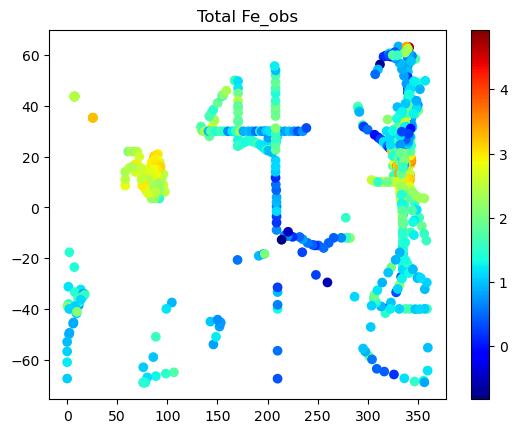

In [161]:
plt.scatter(ds_ito.lon,ds_ito.lat, c=np.log10(ds_ito.TotalFe_obs),cmap='jet')
plt.colorbar()
plt.title('Total Fe_obs')

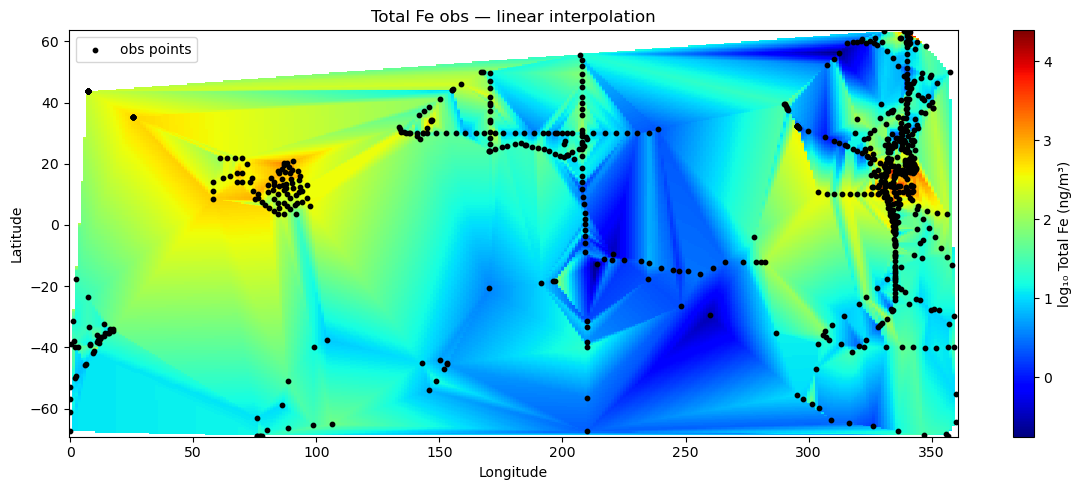

In [181]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────────────────────────────
lon     = ds_ito.lon.values
lat     = ds_ito.lat.values
fe      = np.log10(ds_ito.TotalFe_obs.values)

# ── Regular grid ──────────────────────────────────────────────────────────────
lon_grid = np.linspace(lon.min(), lon.max(), 300)
lat_grid = np.linspace(lat.min(), lat.max(), 300)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

# ── Interpolate ───────────────────────────────────────────────────────────────
FE_grid = griddata(
    points=(lon, lat),
    values=fe,
    xi=(LON, LAT),
    method='linear'
)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.pcolormesh(LON, LAT, FE_grid, cmap='jet', shading='auto')
plt.colorbar(label='log₁₀ Total Fe (ng/m³)')
plt.scatter(lon, lat, c='k', s=10, label='obs points')  # overlay original points
plt.title('Total Fe obs — linear interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()

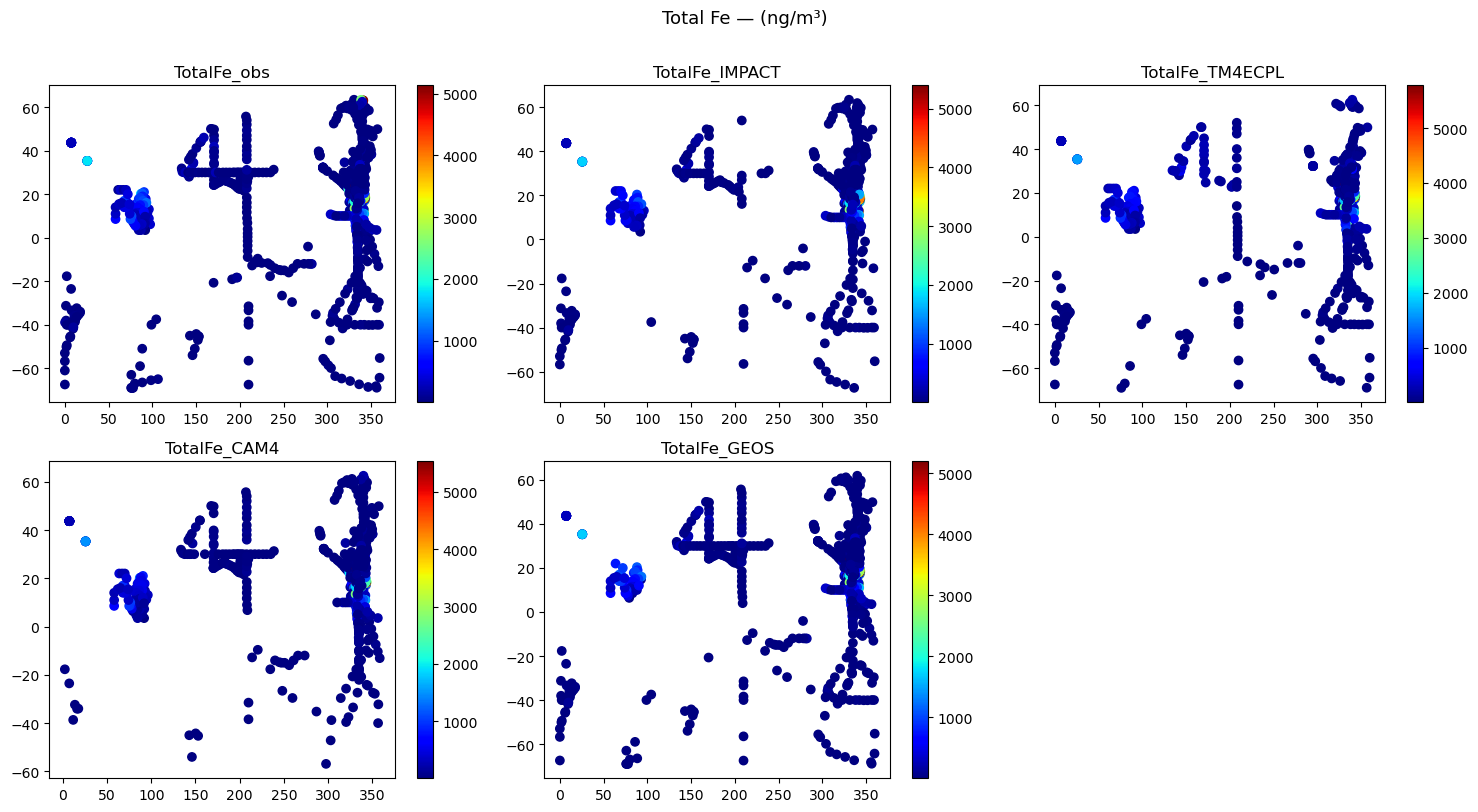

In [175]:
models = ['TotalFe_obs', 'TotalFe_IMPACT', 'TotalFe_TM4ECPL', 'TotalFe_CAM4', 'TotalFe_GEOS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(models):
    sc = axes[i].scatter(
        ds_ito.lon, ds_ito.lat,
        c=ds_ito[var],
        cmap='jet',
        vmin=np.nanpercentile(ds_ito[var], 2),
        vmax=np.nanpercentile(ds_ito[var], 98)
    )
    plt.colorbar(sc, ax=axes[i])
    axes[i].set_title(var)

axes[-1].set_visible(False)   # hide empty 6th panel

plt.suptitle('Total Fe — (ng/m³)', fontsize=13, y=1.01)

plt.tight_layout()
# plt.savefig('ito_Total_Fe.png', dpi=150, bbox_inches='tight')
plt.show()


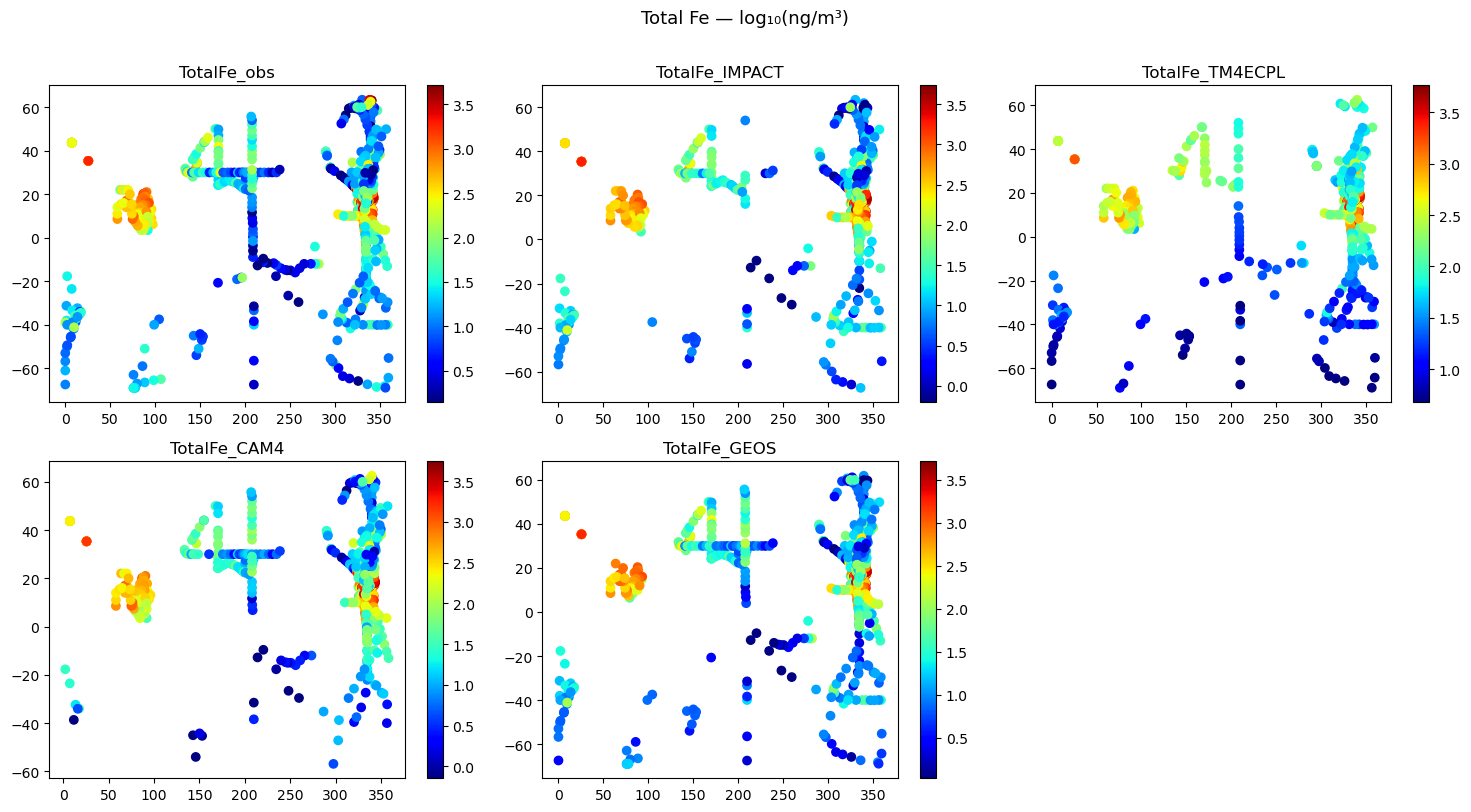

In [176]:
models = ['TotalFe_obs', 'TotalFe_IMPACT', 'TotalFe_TM4ECPL', 'TotalFe_CAM4', 'TotalFe_GEOS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(models):
    sc = axes[i].scatter(
        ds_ito.lon, ds_ito.lat,
        c=np.log10(ds_ito[var]),
        cmap='jet',
        vmin=np.nanpercentile(np.log10(ds_ito[var]), 2),
        vmax=np.nanpercentile(np.log10(ds_ito[var]), 98)
    )
    plt.colorbar(sc, ax=axes[i])
    axes[i].set_title(var)

axes[-1].set_visible(False)   # hide empty 6th panel

plt.suptitle('Total Fe — log₁₀(ng/m³)', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('ito_Total_Fe_log10.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

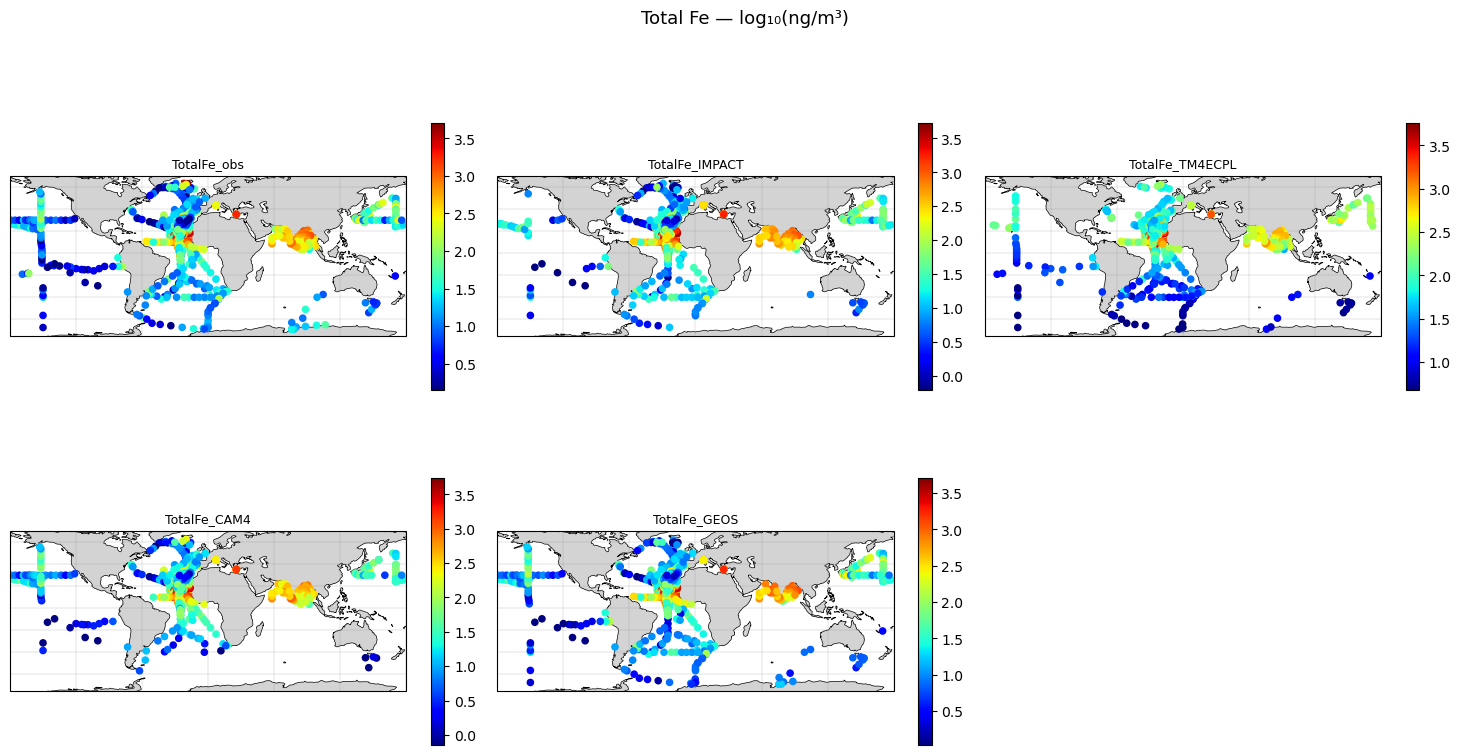

In [187]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

models = ['TotalFe_obs', 'TotalFe_IMPACT', 'TotalFe_TM4ECPL', 'TotalFe_CAM4', 'TotalFe_GEOS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, var in enumerate(models):
    ax = axes[i]
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    sc = ax.scatter(
        ds_ito.lon, ds_ito.lat,
        c=np.log10(ds_ito[var]),
        cmap='jet',
        vmin=np.nanpercentile(np.log10(ds_ito[var]), 2),
        vmax=np.nanpercentile(np.log10(ds_ito[var]), 98),
        transform=ccrs.PlateCarree(),
        s=20, zorder=2
    )
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(var, fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Total Fe — log₁₀(ng/m³)', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('ito_Total_Fe_log10_map.png', dpi=150, bbox_inches='tight')

plt.show()

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/C

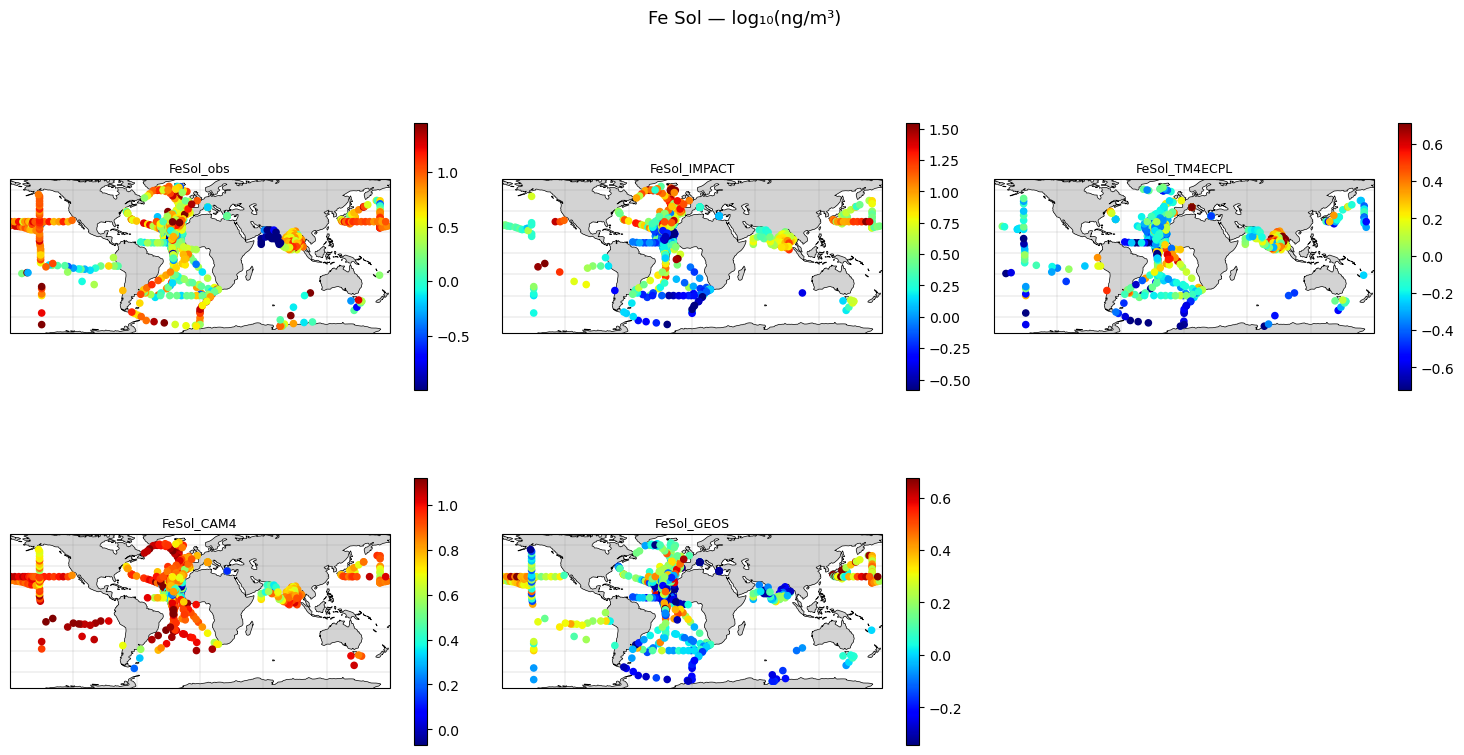

In [189]:
models = ['FeSol_obs', 'FeSol_IMPACT', 'FeSol_TM4ECPL', 'FeSol_CAM4', 'FeSol_GEOS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, var in enumerate(models):
    ax = axes[i]
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    sc = ax.scatter(
        ds_ito.lon, ds_ito.lat,
        c=np.log10(ds_ito[var]),
        cmap='jet',
        vmin=np.nanpercentile(np.log10(ds_ito[var]), 2),
        vmax=np.nanpercentile(np.log10(ds_ito[var]), 98),
        transform=ccrs.PlateCarree(),
        s=20, zorder=2
    )
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(var, fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Fe Sol — log₁₀(ng/m³)', fontsize=13, y=1.01)
plt.tight_layout()
# plt.savefig('ito_FeSol_log10_map.png', dpi=150, bbox_inches='tight')

plt.show()

In [194]:
ds_ito

<xarray.Dataset> Size: 146kB
Dimensions:                       (obs: 795)
Coordinates:
  * obs                           (obs) int64 6kB 16 17 18 19 ... 1040 1041 1042
    lon                           (obs) float64 6kB 80.3 81.8 ... 297.7 295.4
    lat                           (obs) float64 6kB 13.1 15.49 ... -56.88 -55.62
    ocean                         (obs) object 6kB 'Bay_of_Bengal' ... 'SO At...
Data variables: (12/19)
    TotalFe_obs                   (obs) float64 6kB 908.9 666.5 ... 8.385 10.32
    TotalFe_IMPACT                (obs) float64 6kB 680.4 707.3 ... 5.676 7.349
    TotalFe_TM4ECPL               (obs) float64 6kB nan nan ... 6.516 6.508
    TotalFe_CAM4                  (obs) float64 6kB nan 393.1 ... 4.169 nan
    TotalFe_GEOS                  (obs) float64 6kB nan nan nan ... 6.734 9.436
    FeSol_obs                     (obs) float64 6kB 7.65 5.805 ... 4.443 13.74
    ...                            ...
    FeSol_comb_dust_TM4ECPL_dust  (obs) float64 6kB nan nan nan ... nan nan nan
    FeSol_comb_dust_CAM4_comb     (obs) float64 6kB nan nan ... 0.5242 2.372
    FeSol_comb_dust_CAM4_dust     (obs) float64 6kB nan nan ... 0.2369 0.1944
    SolFe_comb_contrib_IMPACT     (obs) float64 6kB 6.238 6.537 ... nan nan
    SolFe_comb_contrib_TM4ECPL    (obs) float64 6kB 7.188 6.89 7.588 ... nan nan
    SolFe_comb_contrib_CAM4       (obs) float64 6kB nan nan nan ... nan nan nan
Attributes:
    title:          Ito et al. SciAdv/SOLAS — Fe observations & model comparison
    TotalFe_units:  ng/m3
    FeSol_units:    %

/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/usr/local/Cellar/micromamba/2.1.1_1/envs/parcels-dev/lib/pytho

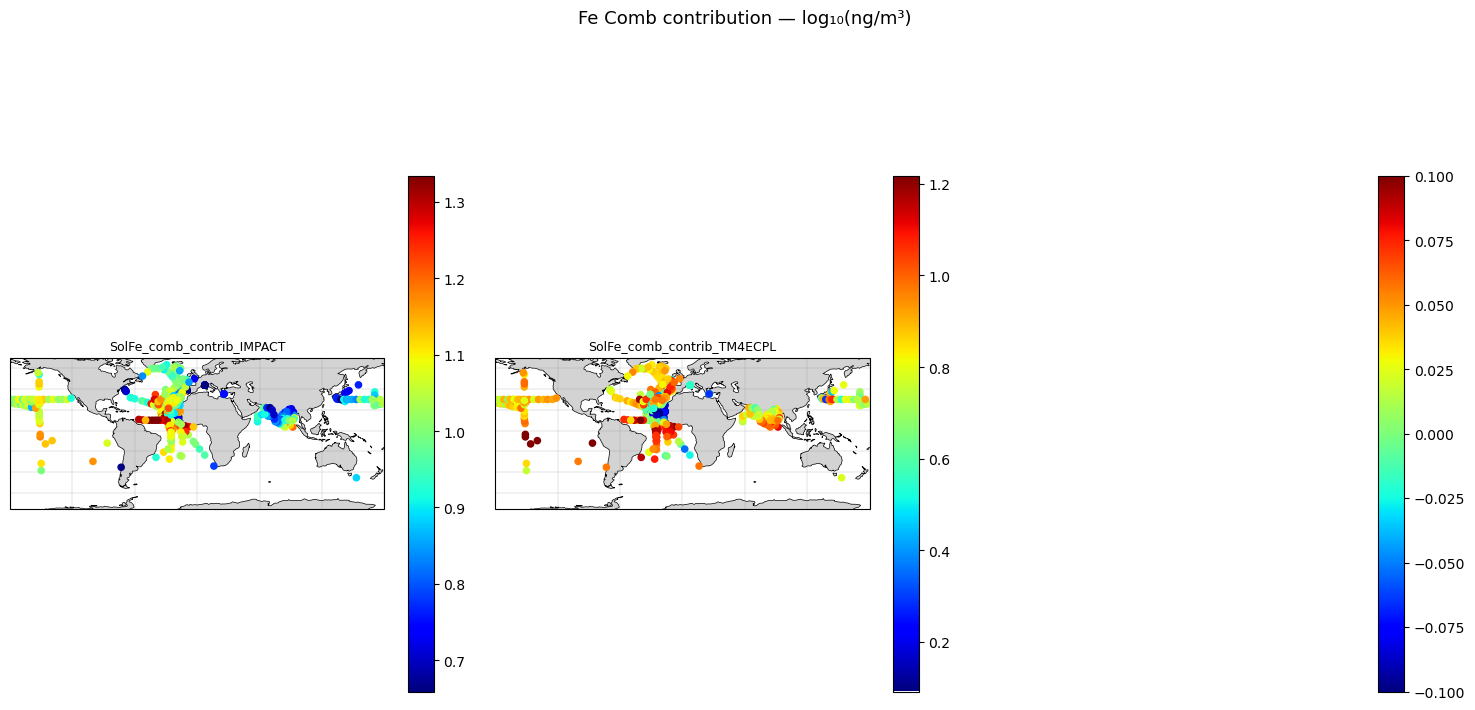

In [199]:
models = ['SolFe_comb_contrib_IMPACT', 'SolFe_comb_contrib_TM4ECPL', 'SolFe_comb_contrib_CAM4']

fig, axes = plt.subplots(1, 3, figsize=(15, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, var in enumerate(models):
    ax = axes[i]
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

    sc = ax.scatter(
        ds_ito.lon, ds_ito.lat,
        c=np.log10(ds_ito[var]),
        cmap='jet',
        vmin=np.nanpercentile(np.log10(ds_ito[var]), 2),
        vmax=np.nanpercentile(np.log10(ds_ito[var]), 98),
        transform=ccrs.PlateCarree(),
        s=20, zorder=2
    )
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(var, fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Fe Comb contribution — log₁₀(ng/m³)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

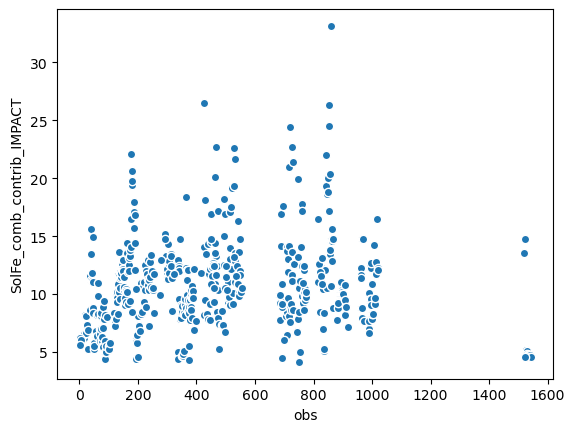

In [202]:
ds_ito.SolFe_comb_contrib_IMPACT.plot.scatter()

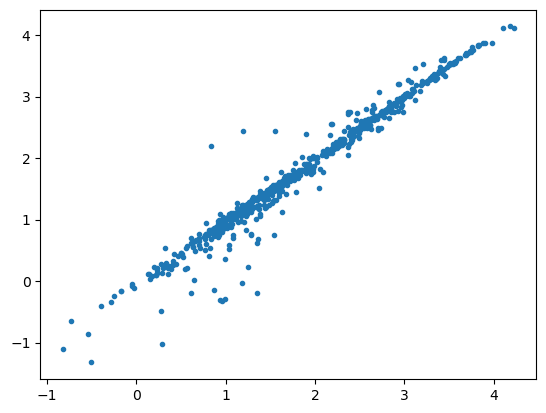

In [165]:
plt.scatter(np.log10(ds_ito.TotalFe_obs), np.log10(ds_ito.TotalFe_IMPACT), marker='.')

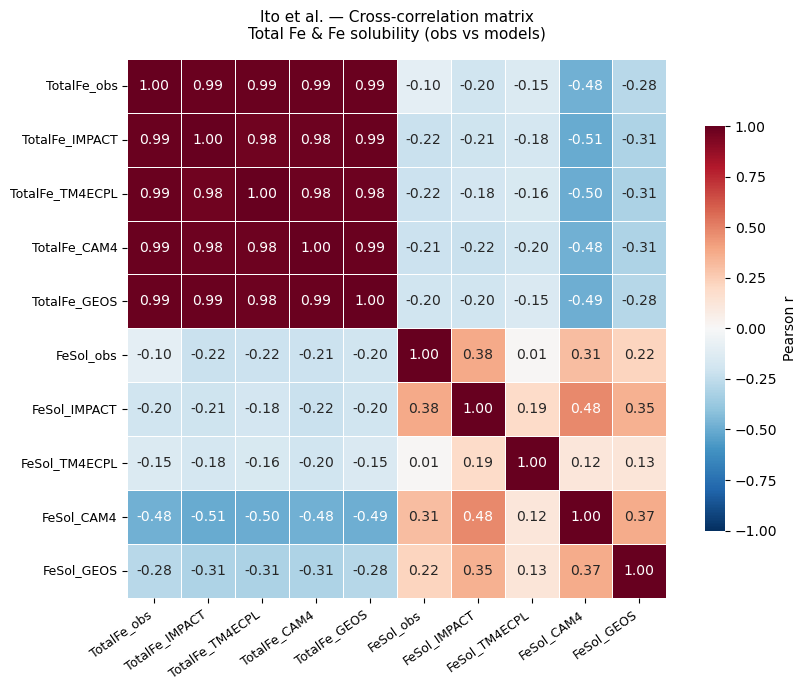

                 TotalFe_obs  TotalFe_IMPACT  TotalFe_TM4ECPL  TotalFe_CAM4  TotalFe_GEOS  FeSol_obs  FeSol_IMPACT  FeSol_TM4ECPL  FeSol_CAM4  FeSol_GEOS
TotalFe_obs             1.00            0.99             0.99          0.99          0.99      -0.10         -0.20          -0.15       -0.48       -0.28
TotalFe_IMPACT          0.99            1.00             0.98          0.98          0.99      -0.22         -0.21          -0.18       -0.51       -0.31
TotalFe_TM4ECPL         0.99            0.98             1.00          0.98          0.98      -0.22         -0.18          -0.16       -0.50       -0.31
TotalFe_CAM4            0.99            0.98             0.98          1.00          0.99      -0.21         -0.22          -0.20       -0.48       -0.31
TotalFe_GEOS            0.99            0.99             0.98          0.99          1.00      -0.20         -0.20          -0.15       -0.49       -0.28
FeSol_obs              -0.10           -0.22            -0.22         -0.21 

In [166]:
# ── Build DataFrame from ds_ito ───────────────────────────────────────────────
variables = ['TotalFe_obs', 'TotalFe_IMPACT', 'TotalFe_TM4ECPL', 'TotalFe_CAM4', 'TotalFe_GEOS',
             'FeSol_obs', 'FeSol_IMPACT', 'FeSol_TM4ECPL', 'FeSol_CAM4', 'FeSol_GEOS']

df_ito = pd.DataFrame({var: ds_ito[var].values for var in variables})

# ── Correlation matrix ────────────────────────────────────────────────────────
corr = df_ito.corr()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)

ax.set_title('Ito et al. — Cross-correlation matrix\nTotal Fe & Fe solubility (obs vs models)',
             fontsize=11, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
# plt.savefig('ito_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr.round(2).to_string())

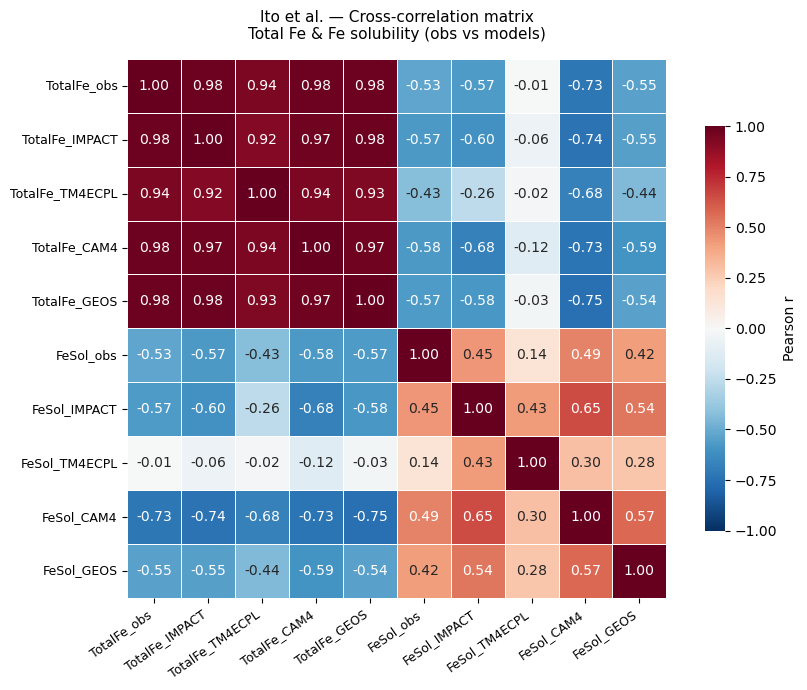

                 TotalFe_obs  TotalFe_IMPACT  TotalFe_TM4ECPL  TotalFe_CAM4  TotalFe_GEOS  FeSol_obs  FeSol_IMPACT  FeSol_TM4ECPL  FeSol_CAM4  FeSol_GEOS
TotalFe_obs             1.00            0.98             0.94          0.98          0.98      -0.53         -0.57          -0.01       -0.73       -0.55
TotalFe_IMPACT          0.98            1.00             0.92          0.97          0.98      -0.57         -0.60          -0.06       -0.74       -0.55
TotalFe_TM4ECPL         0.94            0.92             1.00          0.94          0.93      -0.43         -0.26          -0.02       -0.68       -0.44
TotalFe_CAM4            0.98            0.97             0.94          1.00          0.97      -0.58         -0.68          -0.12       -0.73       -0.59
TotalFe_GEOS            0.98            0.98             0.93          0.97          1.00      -0.57         -0.58          -0.03       -0.75       -0.54
FeSol_obs              -0.53           -0.57            -0.43         -0.58 

In [190]:
# ── Correlation matrix ────────────────────────────────────────────────────────
corr = np.log10(df_ito).corr()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)

ax.set_title('Ito et al. — Cross-correlation matrix\nTotal Fe & Fe solubility (obs vs models)',
             fontsize=11, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
# plt.savefig('ito_correlation_matrix_LOG10.png', dpi=150, bbox_inches='tight')
plt.show()

print(corr.round(2).to_string())

In [193]:
ds_ito

<xarray.Dataset> Size: 146kB
Dimensions:                       (obs: 795)
Coordinates:
  * obs                           (obs) int64 6kB 16 17 18 19 ... 1040 1041 1042
    lon                           (obs) float64 6kB 80.3 81.8 ... 297.7 295.4
    lat                           (obs) float64 6kB 13.1 15.49 ... -56.88 -55.62
    ocean                         (obs) object 6kB 'Bay_of_Bengal' ... 'SO At...
Data variables: (12/19)
    TotalFe_obs                   (obs) float64 6kB 908.9 666.5 ... 8.385 10.32
    TotalFe_IMPACT                (obs) float64 6kB 680.4 707.3 ... 5.676 7.349
    TotalFe_TM4ECPL               (obs) float64 6kB nan nan ... 6.516 6.508
    TotalFe_CAM4                  (obs) float64 6kB nan 393.1 ... 4.169 nan
    TotalFe_GEOS                  (obs) float64 6kB nan nan nan ... 6.734 9.436
    FeSol_obs                     (obs) float64 6kB 7.65 5.805 ... 4.443 13.74
    ...                            ...
    FeSol_comb_dust_TM4ECPL_dust  (obs) float64 6kB nan nan nan ... nan nan nan
    FeSol_comb_dust_CAM4_comb     (obs) float64 6kB nan nan ... 0.5242 2.372
    FeSol_comb_dust_CAM4_dust     (obs) float64 6kB nan nan ... 0.2369 0.1944
    SolFe_comb_contrib_IMPACT     (obs) float64 6kB 6.238 6.537 ... nan nan
    SolFe_comb_contrib_TM4ECPL    (obs) float64 6kB 7.188 6.89 7.588 ... nan nan
    SolFe_comb_contrib_CAM4       (obs) float64 6kB nan nan nan ... nan nan nan
Attributes:
    title:          Ito et al. SciAdv/SOLAS — Fe observations & model comparison
    TotalFe_units:  ng/m3
    FeSol_units:    %